In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../shared").resolve()))
sys.path.insert(0, str(Path(".").resolve()))

from constants import (
    ARM_LINK,
    CAPTIONS_PATH,
    CARTESIAN_CONTROL_CACHE_PATH,
    CC_A_MAX_EL_NEG,
    CC_A_MAX_EL_POS,
    CC_A_MAX_SH_NEG,
    CC_A_MAX_SH_POS,
    CC_ABLATION_RESULTS_DIR,
    CC_AMP_REG,
    CC_BAND_CHANNELS,
    CC_DIST_THRESH,
    CC_EL_THRESH,
    CC_N_R,
    CC_N_THETA,
    CC_OPEN_LOOP_OFFSET,
    CC_OPTIMAL_PARAMS_PATH,
    CC_Q_INT,
    CC_Q_TRACK,
    CC_R_EFFORT,
    CC_SH_THRESH,
    CC_SH_DRIFT_THRESH,
    CC_T,
    CC_TARGET_R_MAX,
    CC_TARGET_R_MIN,
    CC_USE_LQI,
    ERA_EM_4_PATH,
    FIGURES_PATH,
    MAX_DELTA,
)
from pgf_utils import (
    apply_figure_style,
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from cartesian_control import run_cartesian_control, aggregate_seed_metrics
from cartesian_control_ablation_elbow import (
    NOTEBOOK_GITHUB_URL,
    make_elbow_figure,
)

In [2]:
# ── 2. Constants ──────────────────────────────────────────────────────────────
ABLATION_SEEDS = list(range(10))
CONDITIONS = {
    "Unconstrained": {"constrain_elbow": False},
    "Constrained":   {"constrain_elbow": True},
}

In [3]:
# ── 3. Derived variables ──────────────────────────────────────────────────────
if CC_OPTIMAL_PARAMS_PATH.exists():
    with open(CC_OPTIMAL_PARAMS_PATH) as fh:
        optimal_params = json.load(fh)
    print(f"Loaded optimal params from {CC_OPTIMAL_PARAMS_PATH.name}")
else:
    optimal_params = {}
    print("Optimal params not found — using defaults from constants.py")

CC_ABLATION_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

base_params = dict(
    cache_path=CARTESIAN_CONTROL_CACHE_PATH,
    estimator_path=ERA_EM_4_PATH,
    T=CC_T, n_r=CC_N_R, n_theta=CC_N_THETA,
    target_r_min=CC_TARGET_R_MIN, target_r_max=CC_TARGET_R_MAX,
    dist_thresh=CC_DIST_THRESH, arm_link=ARM_LINK, max_delta=MAX_DELTA,
    q_track=CC_Q_TRACK, r_effort=CC_R_EFFORT, q_int=CC_Q_INT,
    el_thresh=CC_EL_THRESH, sh_thresh=CC_SH_THRESH,
    sh_drift_thresh=CC_SH_DRIFT_THRESH,
    a_max_sh_pos=CC_A_MAX_SH_POS, a_max_sh_neg=CC_A_MAX_SH_NEG,
    a_max_el_pos=CC_A_MAX_EL_POS, a_max_el_neg=CC_A_MAX_EL_NEG,
    amp_reg=CC_AMP_REG,
    use_lqi=CC_USE_LQI,
    band_channels=CC_BAND_CHANNELS, open_loop_offset=CC_OPEN_LOOP_OFFSET,
)

Loaded optimal params from cc_optimal_params.json


In [4]:
# ── 4. Simulation ─────────────────────────────────────────────────────────────
ablation_results = {}
for cond_name, overrides in CONDITIONS.items():
    per_seed: list = []
    for seed in ABLATION_SEEDS:
        slug = cond_name.lower()
        results, _, _ = run_cartesian_control(
            **{**base_params, **optimal_params, **overrides},
            demo_seed=seed,
            results_path=CC_ABLATION_RESULTS_DIR / f"elbow_{slug}_{seed}.pkl",
        )
        per_seed.append(results)
    ablation_results[cond_name] = aggregate_seed_metrics(
        per_seed, T=CC_T, dist_thresh=CC_DIST_THRESH
    )

print("\nAblation summary (mean ± SD across seeds):")
for cond, agg in ablation_results.items():
    fd = agg["final_dist"]
    el = agg["final_el_err_deg"]
    print(f"  {cond:<15}: final_dist={fd.mean():.2f}±{fd.std():.2f}  el_err_deg={el.mean():.2f}±{el.std():.2f}")

Loading cached results from elbow_unconstrained_0.pkl
Loading cached results from elbow_unconstrained_1.pkl
Loading cached results from elbow_unconstrained_2.pkl
Loading cached results from elbow_unconstrained_3.pkl
Loading cached results from elbow_unconstrained_4.pkl
Loading cached results from elbow_unconstrained_5.pkl
Loading cached results from elbow_unconstrained_6.pkl
Loading cached results from elbow_unconstrained_7.pkl
Loading cached results from elbow_unconstrained_8.pkl
Loading cached results from elbow_unconstrained_9.pkl
Loading cached results from elbow_constrained_0.pkl
Loading cached results from elbow_constrained_1.pkl
Loading cached results from elbow_constrained_2.pkl
Loading cached results from elbow_constrained_3.pkl
Loading cached results from elbow_constrained_4.pkl
Loading cached results from elbow_constrained_5.pkl
Loading cached results from elbow_constrained_6.pkl
Loading cached results from elbow_constrained_7.pkl
Loading cached results from elbow_constraine

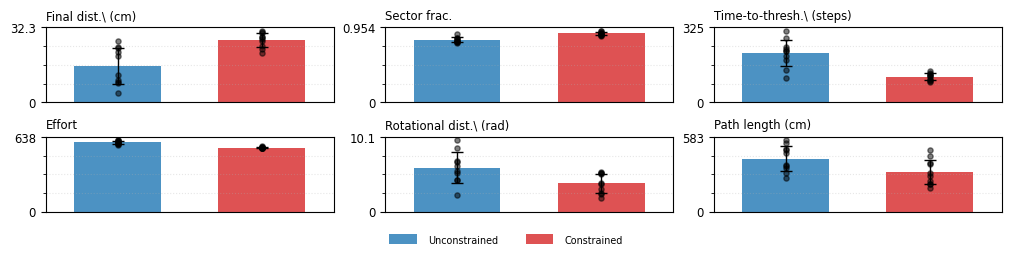

In [5]:
# ── 5. Display ────────────────────────────────────────────────────────────────
configure_screen()
fig = make_elbow_figure(ablation_results, figsize=(10.0, 2.5))
apply_figure_style(fig)
plt.show()

In [8]:
# ── 6. PGF export ─────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 0.50
FIG_HEIGHT_FRAC = 0.25

configure_pgf()
fig = make_elbow_figure(
    ablation_results,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "cartesian_control_ablation_elbow.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/cartesian_control_ablation_elbow.pgf


In [7]:
# ── 7. Caption ────────────────────────────────────────────────────────────────
n_seeds  = len(ABLATION_SEEDS)
n_trials = CC_N_R * CC_N_THETA

un_fd = ablation_results["Unconstrained"]["final_dist"]
co_fd = ablation_results["Constrained"]["final_dist"]
un_el = ablation_results["Unconstrained"]["final_el_err_deg"]
co_el = ablation_results["Constrained"]["final_el_err_deg"]

caption = (
    r"Ablation comparing unconstrained and anatomically constrained elbow "
    r"($\theta_\mathrm{el} \in [0, \pi]$) on "
    f"{n_trials} targets across $N={n_seeds}$ Brain seeds "
    f"($T={CC_T}$ steps). "
    r"Bars show mean across seeds; error bars and dots show ±\,1\,SD and "
    r"individual seed means. "
    f"Unconstrained final distance: ${un_fd.mean():.1f} \\pm {un_fd.std():.1f}$\\,cm "
    f"(elbow error ${un_el.mean():.1f}^\\circ$); "
    f"constrained: ${co_fd.mean():.1f} \\pm {co_fd.std():.1f}$\\,cm "
    f"(elbow error ${co_el.mean():.1f}^\\circ$)."
)

save_caption(
    CAPTIONS_PATH / "cartesian_control_ablation_elbow.tex",
    caption, NOTEBOOK_GITHUB_URL,
)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/cartesian_control_ablation_elbow.tex
Ablation comparing unconstrained and anatomically constrained elbow ($\theta_\mathrm{el} \in [0, \pi]$) on 24 targets across $N=10$ Brain seeds ($T=1000$ steps). Bars show mean across seeds; error bars and dots show ±\,1\,SD and individual seed means. Unconstrained final distance: $15.8 \pm 7.7$\,cm (elbow error $29.0^\circ$); constrained: $26.9 \pm 3.1$\,cm (elbow error $5.3^\circ$).
